# 9장 실습 — 뉴로모픽 데이터셋 다루기 (Tonic)

**Spiking Neural Networks 쿡북 with Python** · 9장 실습 노트북

이벤트 카메라 데이터셋 **N-MNIST**를 Tonic으로 불러와 프레임으로 변환하고, SNN에 넣을 준비를 한다.

### 학습 목표
- `tonic.datasets.NMNIST`로 이벤트 데이터를 불러온다.
- `Denoise`+`ToFrame`으로 이벤트를 프레임으로 변환한다.
- `DiskCachedDataset`과 `PadTensors`로 데이터로더를 구성한다.
- 프레임을 받는 합성곱 SNN을 정의하고 한 배치를 통과시킨다.

> 이 책의 실습 코드는 가독성을 위해 `if`문과 `try/except` 예외처리를 사용하지 않는다.

## 1. 설치와 임포트

`tonic`은 뉴로모픽 데이터셋 라이브러리다.

In [1]:
%pip install -q tonic

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import tonic
import tonic.transforms as transforms   # 이벤트 변환 (torchvision과 다름)
import torch
import matplotlib.pyplot as plt
import koreanize_matplotlib

/opt/miniconda3/envs/RL/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. N-MNIST 불러오기

첫 샘플을 받아 이벤트 배열과 정답 레이블을 확인한다. 각 이벤트는 (x, y, t, 극성)을 담는다.

In [3]:
dataset = tonic.datasets.NMNIST(save_to='./data', train=True)
events, target = dataset[0]
print('정답 레이블:', target)
print('이벤트 개수:', len(events))
print('첫 이벤트(x,y,t,p):', events[0])

정답 레이블: 0
이벤트 개수: 5028
첫 이벤트(x,y,t,p): (10, 30, 937, 1)


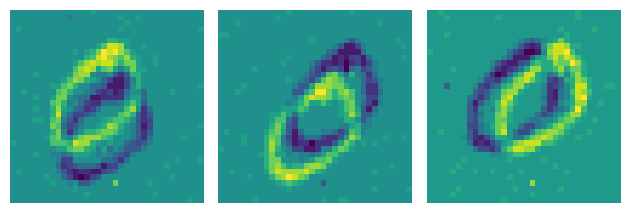

In [4]:
# 이벤트를 격자에 누적해 시각화
tonic.utils.plot_event_grid(events)
plt.show()

## 3. 이벤트 → 프레임 변환

`Denoise`로 고립된 잡음 이벤트를 걸러내고, `ToFrame`으로 일정 시간 창의 이벤트를 프레임으로 누적한다. 센서 크기는 데이터셋이 알려준다(N-MNIST는 34×34×2).

In [5]:
sensor_size = tonic.datasets.NMNIST.sensor_size   # (34, 34, 2)

frame_transform = transforms.Compose([
    transforms.Denoise(filter_time=10000),                 # 잡음 제거
    transforms.ToFrame(
        sensor_size=sensor_size, 
        time_window=1000),   # 1ms 창으로 프레임화
])

trainset = tonic.datasets.NMNIST(
    save_to='./data', 
    transform=frame_transform, 
    train=True
)
testset = tonic.datasets.NMNIST(
    save_to='./data', 
    transform=frame_transform, 
    train=False
)

frames, target = trainset[0]
print('프레임 텐서 형태 (시간, 극성, 높이, 너비):', frames.shape)

프레임 텐서 형태 (시간, 극성, 높이, 너비): (298, 2, 34, 34)


## 4. 빠른 데이터 로딩 — 캐싱과 콜레이트

변환 결과를 `DiskCachedDataset`으로 디스크에 캐싱하면 두 번째 에폭부터 빨라진다. 이벤트 샘플은 길이가 제각각이라 `PadTensors` 콜레이트로 배치 안에서 길이를 맞춘다.

In [6]:
from torch.utils.data import DataLoader
from tonic import DiskCachedDataset

cached_trainset = DiskCachedDataset(
    trainset, 
    cache_path='./cache/nmnist/train'
)
cached_testset = DiskCachedDataset(
    testset, 
    cache_path='./cache/nmnist/test'
)

batch_size = 128
trainloader = DataLoader(
    cached_trainset, 
    batch_size=batch_size, 
    shuffle=True,
    collate_fn=tonic.collation.PadTensors(batch_first=False)
)
testloader = DataLoader(
    cached_testset, 
    batch_size=batch_size,
    collate_fn=tonic.collation.PadTensors(batch_first=False)
)

event_tensor, target = next(iter(trainloader))
print('배치 텐서 형태 (시간, 배치, 극성, H, W):', event_tensor.shape)

배치 텐서 형태 (시간, 배치, 극성, H, W): torch.Size([310, 128, 2, 34, 34])


## 5. 프레임을 받는 합성곱 SNN 정의

입력은 2채널(ON/OFF 극성) 프레임이다. 8장과 같은 Conv–Pool–LIF 구조이되, 첫 합성곱의 입력 채널만 2로 둔다. 한 배치를 시간 축을 따라 통과시켜 출력 형태를 확인한다(학습은 8장과 동일하므로 여기서는 한 번의 순전파만 본다).

In [7]:
import torch.nn as nn
import snntorch as snn
from snntorch import surrogate, utils

spike_grad = surrogate.fast_sigmoid()
beta = 0.5

net = nn.Sequential(
    nn.Conv2d(2, 12, 5),                 # 입력 2채널(ON/OFF)
    nn.MaxPool2d(2),
    snn.Leaky(beta=beta, spike_grad=spike_grad, init_hidden=True),
    nn.Conv2d(12, 32, 5),
    nn.MaxPool2d(2),
    snn.Leaky(beta=beta, spike_grad=spike_grad, init_hidden=True),
    nn.Flatten(),
    nn.Linear(32 * 5 * 5, 10),
    snn.Leaky(
        beta=beta, 
        spike_grad=spike_grad, 
        init_hidden=True, 
        output=True
    ),
)

# 한 배치를 시간 축(첫 차원)을 따라 순전파
data = event_tensor.float()
num_steps = data.size(0)
utils.reset(net)
spk_rec = []
for step in range(num_steps):
    spk_out, mem_out = net(data[step])
    spk_rec.append(spk_out)
spk_rec = torch.stack(spk_rec)
print('출력 스파이크 형태 (시간, 배치, 10):', spk_rec.shape)

출력 스파이크 형태 (시간, 배치, 10): torch.Size([310, 128, 10])


## 정리

- `tonic.datasets.NMNIST`로 이벤트 데이터를 한 줄로 불러온다.
- `Denoise`+`ToFrame`으로 이벤트를 (시간, 극성, H, W) 프레임으로 만든다.
- `DiskCachedDataset`+`PadTensors`로 빠르고 일관된 배치를 만든다.
- 입력 채널만 2로 둔 CSNN으로, 이후 학습은 8장과 완전히 동일하다.